### Try to beat the Bayesian strategy

##### 1. Reproduce example from the lecture (electronic system production)

In [1]:
import numpy as np

class Batch:
    quality = 0.5
    alpha = 1
    beta = 1

    def __init__(self, quality):
        self.quality = quality

    def sample_distribution(self):
        return np.random.beta(self.alpha, self.beta)

    def get_element(self):
        good = np.random.rand() < self.quality
        self.alpha = self.alpha + int(good)
        self.beta = self.beta + 1 - int(good)
        return good


class Factory:
    batches = []
    systems = 0
    good = 0

    def set_batches(self, qualities):
        self.batches = [Batch(quality) for quality in qualities]
        self.systems = 0
        self.good = 0

    def get_element(self):
        samples = [batch.sample_distribution() for batch in self.batches]
        choice = np.argmax(samples)
        result = self.batches[choice].get_element()
        self.systems = self.systems + 1
        self.good = self.good + int(result)

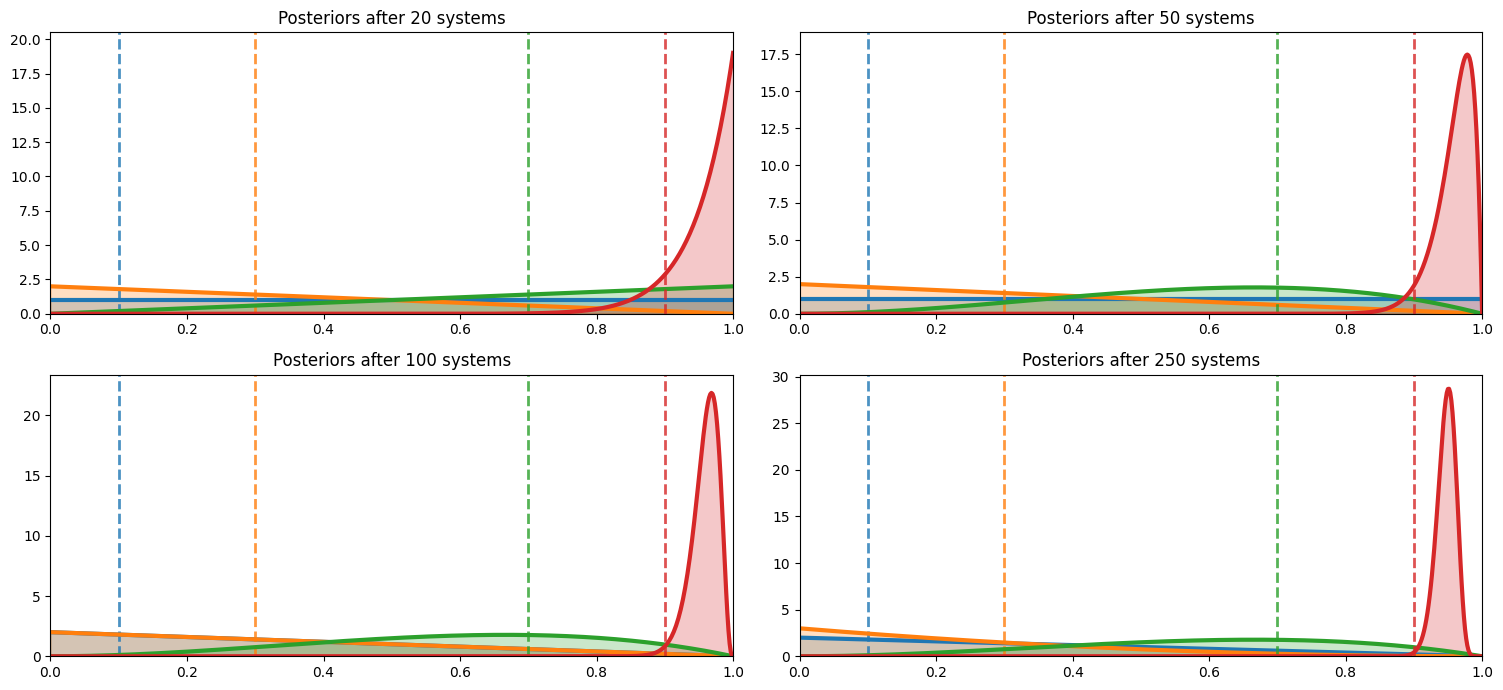

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import beta


qualities = [0.1, 0.3, 0.7, 0.9]
factory = Factory()
factory.set_batches(qualities)

checkpoints = [20, 50, 100, 250]
max_steps = max(checkpoints)

snapshots = {}

for step in range(1, max_steps + 1):
    factory.get_element()
    if step in checkpoints:
        snapshots[step] = [(b.alpha, b.beta, b.quality) for b in factory.batches]


x = np.linspace(0, 1, 600)
colors = ['C0', 'C1', 'C2', 'C3']
labels = [f'partia {i+1}' for i in range(len(qualities))]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
axes = axes.flatten()

for ax, step in zip(axes, checkpoints):
    ax.set_title(f'Posteriors after {step} systems')

    for i, (a, b_, q) in enumerate(snapshots[step]):
        y = beta.pdf(x, a, b_)
        ax.plot(x, y, color=colors[i], lw=3)
        ax.fill_between(x, y, color=colors[i], alpha=0.25)
        ax.axvline(q, color=colors[i], linestyle='--', lw=2, alpha=0.8)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(y) + 1.5)

plt.tight_layout()
plt.show()


##### 2. Implement last three strategies from slide 105 plus one of your own (other than the two remaining in the slide), compare results in a plot.

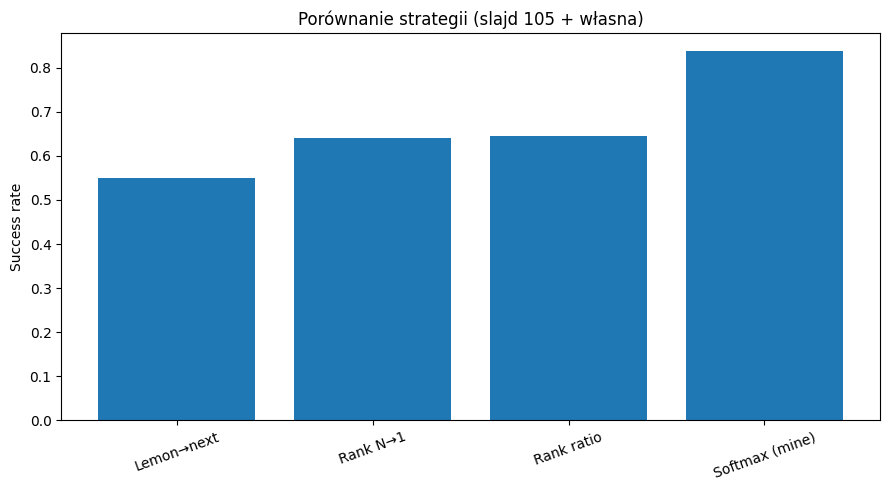

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def strat_lemon_next(factory, steps):
    good = np.zeros(len(factory.batches))
    total = np.zeros(len(factory.batches))
    current = 0

    for _ in range(steps):
        choice = current
        result = factory.batches[choice].get_element()

        good[choice] += int(result)
        total[choice] += 1

        if good[choice] < total[choice]:
            current = (choice + 1) % len(factory.batches)

    return sum(good) / sum(total)

def strat_rank_desc(factory, steps):
    N = len(factory.batches)
    good = np.zeros(N)
    total = np.zeros(N)

    for t in range(steps):
        s = np.divide(good, total, out=np.zeros_like(good), where=total > 0)

        order = np.argsort(-s)

        schedule = []
        for i, idx in enumerate(order):
            schedule += [idx] * (N - i)

        choice = schedule[t % len(schedule)]

        result = factory.batches[choice].get_element()
        good[choice] += int(result)
        total[choice] += 1

    return sum(good) / sum(total)


def strat_rank_ratio(factory, steps):
    N = len(factory.batches)
    good = np.zeros(N)
    total = np.zeros(N)

    for t in range(steps):

        s = np.divide(good, total, out=np.zeros_like(good), where=total > 0)

        order = np.argsort(s)
        sorted_s = s[order]

        batch_counts = [1]
        for i in range(1, N):
            if sorted_s[i - 1] == 0:
                r = 2       
            else:
                r = sorted_s[i] / sorted_s[i - 1]

            batch_counts.append(max(1, int(round(batch_counts[-1] * r))))

        schedule = []
        for idx, count in zip(order, batch_counts):
            schedule += [idx] * count

        choice = schedule[t % len(schedule)]
        result = factory.batches[choice].get_element()

        good[choice] += int(result)
        total[choice] += 1

    return sum(good) / sum(total)

def strat_softmax(factory, steps, tau=4.0):
    N = len(factory.batches)
    good = np.zeros(N)
    total = np.zeros(N)

    for t in range(steps):
        s = np.divide(good, total, out=np.zeros_like(good), where=total > 0)
        ex = np.exp(tau * s)
        p = ex / np.sum(ex)

        choice = np.random.choice(N, p=p)

        result = factory.batches[choice].get_element()
        good[choice] += int(result)
        total[choice] += 1

    return sum(good) / sum(total)


qualities = [0.1, 0.3, 0.7, 0.9]
STEPS = 400

results = []

factory = Factory()
factory.set_batches(qualities)
results.append(strat_lemon_next(factory, STEPS))

factory = Factory()
factory.set_batches(qualities)
results.append(strat_rank_desc(factory, STEPS))

factory = Factory()
factory.set_batches(qualities)
results.append(strat_rank_ratio(factory, STEPS))

factory = Factory()
factory.set_batches(qualities)
results.append(strat_softmax(factory, STEPS))

names = ["Lemon→next", "Rank N→1", "Rank ratio", "Softmax (mine)"]

plt.figure(figsize=(9,5))
plt.bar(names, results)
plt.ylabel("Success rate")
plt.xticks(rotation=20)
plt.title("Porównanie strategii (slajd 105 + własna)")
plt.tight_layout()
plt.show()




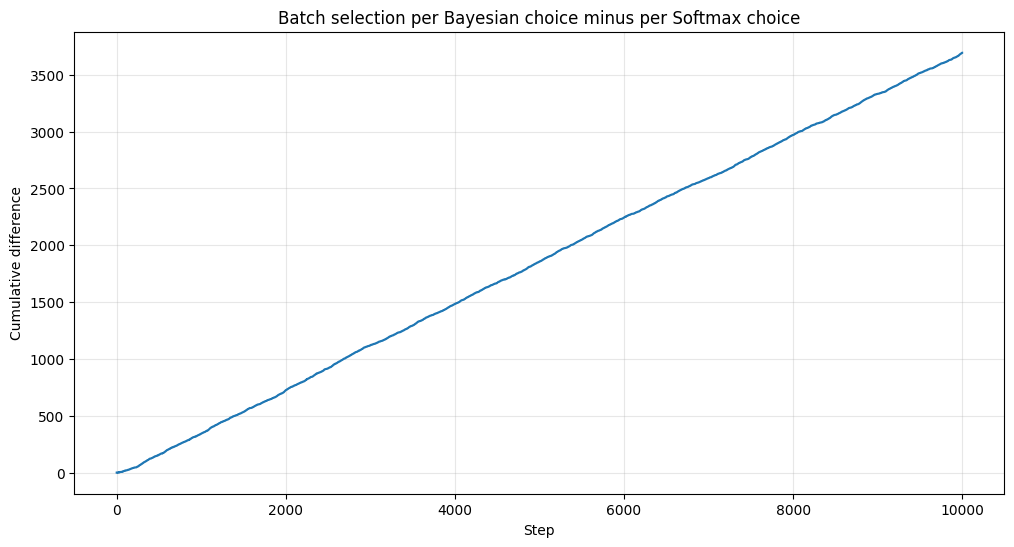

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def thompson_sampling(factory, steps):
    N = len(factory.batches)

    for b in factory.batches:
        b.alpha = 1
        b.beta = 1

    chosen = []

    for t in range(steps):
        samples = [b.sample_distribution() for b in factory.batches]
        choice = np.argmax(samples)
        factory.batches[choice].get_element()
        chosen.append(choice)

    return np.array(chosen)

def softmax_strategy(factory, steps, tau=4.0):
    N = len(factory.batches)

    good = np.zeros(N)
    total = np.zeros(N)
    chosen = []

    for t in range(steps):
        s = np.divide(good, total, out=np.zeros_like(good), where=total>0)
        ex = np.exp(tau * s)
        p = ex / np.sum(ex)
        choice = np.random.choice(N, p=p)

        result = factory.batches[choice].get_element()
        good[choice] += int(result)
        total[choice] += 1
        chosen.append(choice)

    return np.array(chosen)


qualities = [0.1, 0.3, 0.7, 0.9]  
BEST = np.argmax(qualities)

STEPS = 10000

factory = Factory()
factory.set_batches(qualities)
ts_choices = thompson_sampling(factory, STEPS)

factory = Factory()
factory.set_batches(qualities)
sm_choices = softmax_strategy(factory, STEPS, tau=4.0)

ts_best = (ts_choices == BEST).astype(int)
sm_best = (sm_choices == BEST).astype(int)

diff = np.cumsum(ts_best - sm_best)

plt.figure(figsize=(12,6))
plt.plot(diff)
plt.title("Batch selection per Bayesian choice minus per Softmax choice")
plt.xlabel("Step")
plt.ylabel("Cumulative difference")
plt.grid(alpha=0.3)
plt.show()

##### 3. In real life it is possible that the quality of components from a manufacture changes in time. Implement “imperfect memory” in the Bayesian strategy that makes it gradually forget the learned parameters of Beta distribution for each batch. Check using an appropriate example.

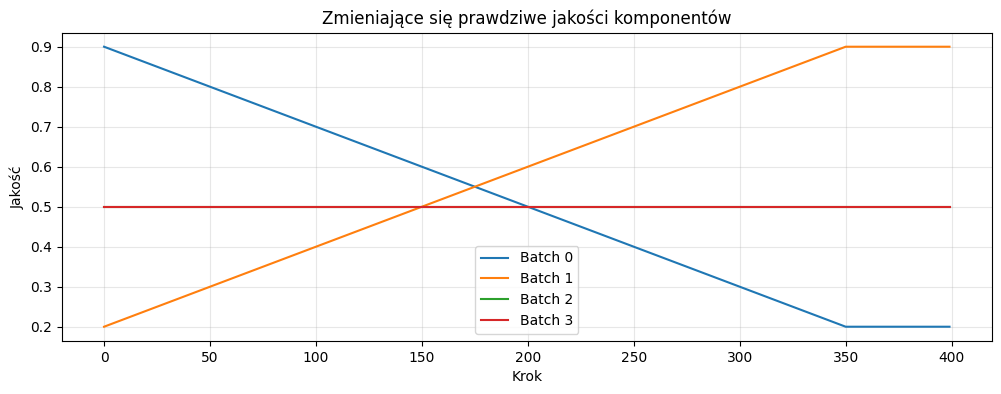

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def ts_imperfect_memory(factory, steps, lam=0.02):
    N = len(factory.batches)

    for b in factory.batches:
        b.alpha = 1
        b.beta = 1

    chosen = []
    true_q_history = []

    for _ in range(steps):
        samples = [b.sample_distribution() for b in factory.batches]
        choice = np.argmax(samples)

        _ = factory.batches[choice].get_element()
        chosen.append(choice)

        for b in factory.batches:
            b.alpha = (1 - lam) * b.alpha
            b.beta  = (1 - lam) * b.beta

        true_q_history.append([b.quality for b in factory.batches])

    return np.array(chosen), np.array(true_q_history)


def update_true_qualities(factory, t):
    factory.batches[0].quality = max(0.9 - 0.002 * t, 0.2)
    factory.batches[1].quality = min(0.2 + 0.002 * t, 0.9)


qualities = [0.9, 0.2, 0.5, 0.5]
STEPS = 400
LAM = 0.03

factory = Factory()
factory.set_batches(qualities)

chosen = []
true_q = []

for t in range(STEPS):
    update_true_qualities(factory, t)
    c, q = ts_imperfect_memory(factory, 1, lam=LAM)
    chosen.extend(c)
    true_q.extend(q)

chosen = np.array(chosen)
true_q = np.array(true_q)

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.plot(true_q[:, i], label=f"Batch {i}")

plt.legend()
plt.title("Zmieniające się prawdziwe jakości komponentów")
plt.xlabel("Krok")
plt.ylabel("Jakość")
plt.grid(alpha=0.3)
plt.show()


**Wnioski**
- Strategia Bayesowska skutecznie identyfikuje najlepszą partię – wraz z rosnącą liczbą próbek jej rozkłady posteriorów szybko koncentrują się wokół rzeczywistych jakości, co widać na wykresach.
- Softmax oraz strategie rankingowe są zauważalnie gorsze od Bayesowskiej, ponieważ potrzebują więcej czasu na eksplorację oraz częściej wybierają słabsze partie, szczególnie gdy początkowe obserwacje są mylące.